<div dir="ltr" align="center">

  <span style="font-size: 60px; color: #0B3C78; font-weight: 700;">
    Artificial Intelligence
  </span><br><br>

  <span style="font-size: 22px; color: #1F5FA8; font-weight: 500;">
    Computer Engineering Department
  </span><br>

  <span style="font-size: 20px; color: #1F5FA8; font-weight: 500;">
    Sharif University of Technology
  </span><br><br>

  <span style="font-size: 22px; color: #1F7A8C; font-weight: 600;">
    Spring 2026
  </span><br><br>

  <span style="font-size: 24px; color: #145DA0; font-weight: 700;">
    Practical Assignment
  </span><br><br>

  <span style="font-size: 22px; color: #3A7CC2; font-weight: 600;">
    Regression
  </span><br><br><br>

</div>

---

- Instructor: Dr.Tanghatari
- Practical Designer: Baran Hosseini

---

### Student Information

- Name: Arvin
- Last Name: Baghal Asl
- Student Number: 403105793

---

### Instructions

- Make sure to:
  - Fill in your personal information above.
  - Run all the cells in the notebook and make sure your code runs truly




# From Linear Optimization to Probabilistic Classification

### Assignment Context
In this module, we explore the backbone of supervised learning. While modern AI often uses complex neural networks, the fundamental logic remains the same: **optimizing a cost function to find weights that generalize to unseen data.**

### Learning Objectives
By the end of this assignment, you will be able to:
1. **Implement Solvers from First Principles:** Understand why we use SVD for closed-form solutions and Gradient Descent for iterative optimization.
2. **Manage the Bias-Variance Tradeoff:** Experiment with high-order polynomials and use L1/L2 regularization to prevent overfitting.
3. **Probabilistic Modeling:** Transition from predicting continuous values to predicting class probabilities using the Logistic Sigmoid function.
4. **Critical Evaluation:** Move beyond simple accuracy to analyze model performance via RMSE, R-Squared, and Confusion Matrices.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

# Seed for reproducibility across random splits and initializations
np.random.seed(42)

# Global plotting configurations
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.4

# Target path configuration
csv_path = "california_housing_raw.csv"

# Load dataset (Assumes the raw CSV is present in the local directory)
try:
    df = pd.read_csv(csv_path)
    print(f"Dataset successfully loaded. Shape: {df.shape}")
    display(df.head())
except FileNotFoundError:
    print(f"Error: '{csv_path}' not found. Please ensure the data file is in the working directory.")

Dataset successfully loaded. Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


### Exploratory Data Analysis & Splitting

Your first goal is to load the California Housing dataset and prepare it for regression. We don't want to evaluate our model on the same data it saw during training, so we must perform a 'Hold-out' split.


In [2]:
# Convert target metric to $100k units
df["median_house_value_100k"] = df["median_house_value"] / 100000.0

target = df["median_house_value_100k"].copy()
raw_features = df.drop(columns=["median_house_value", "median_house_value_100k"])

print("Target Column Summary Statistics ($100k Units):")
display(target.describe().to_frame().T)

# Primary Train/Test Split (80/20)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    raw_features, target.values, test_size=0.2, random_state=42
)

Target Column Summary Statistics ($100k Units):


,count,mean,std,min,25%,50%,75%,max
median_house_value_100k,20640.0,2.068558,1.153956,0.14999,1.196,1.797,2.64725,5.00001


### Feature Engineering & Preprocessing

Real-world data is messy. You will notice the `total_bedrooms` column has missing values. In this section, you will write a pipeline to impute these values, create new 'ratio' features (like rooms per household), and standardize the numerical values so no single feature dominates the model weights.


In [3]:
def add_engineered_features(frame: pd.DataFrame) -> pd.DataFrame:
    df_local = frame.copy()
    eps = 1e-9
    df_local["rooms_per_household"] = df_local["total_rooms"] / (df_local["households"] + eps)
    df_local["bedrooms_per_room"] = df_local["total_bedrooms"] / (df_local["total_rooms"] + eps)
    df_local["population_per_household"] = df_local["population"] / (df_local["households"] + eps)
    return df_local

numeric_cols = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train_raw.select_dtypes(exclude=[np.number]).columns.tolist()

train_medians = X_train_raw[numeric_cols].median()
X_train_imp = X_train_raw.copy()
X_test_imp = X_test_raw.copy()

X_train_imp[numeric_cols] = X_train_imp[numeric_cols].fillna(train_medians)
X_test_imp[numeric_cols] = X_test_imp[numeric_cols].fillna(train_medians)

X_train_fe = add_engineered_features(X_train_imp)
X_test_fe = add_engineered_features(X_test_imp)

X_train_enc = pd.get_dummies(X_train_fe, columns=categorical_cols, drop_first=True)
X_test_enc = pd.get_dummies(X_test_fe, columns=categorical_cols, drop_first=True)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# Hint: Scale based on Training stats and apply to Test.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_enc)
X_test = scaler.transform(X_test_enc)

feature_names = X_train_enc.columns.tolist()
print(f"Processed Training Matrix Shape : {X_train.shape}")
print("feature names: ", feature_names)

Processed Training Matrix Shape : (16512, 15)
feature names:  ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'rooms_per_household', 'bedrooms_per_room', 'population_per_household', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


### Building Solvers From Scratch

Instead of using a library like Scikit-Learn, you are going to implement the linear algebra yourself! This helps you understand what happens 'under the hood.' You'll implement the **Normal Equation (via SVD)** for OLS and **Coordinate Descent** for Lasso.

**Question:**
*   **Solver Comparison:** We use SVD for OLS but an iterative loop for Lasso. Why can't we use a simple closed-form matrix solution for L1 (Lasso) regularization like we do for OLS?

**Answer:** We can't use a quick matrix formula for Lasso because its math creates sharp, pointy corners instead of a perfectly smooth curve. The instant calculus trick we use to solve OLS in a single jump only works on smooth surfaces where we can easily measure the slope at any point. Because that math shortcut completely breaks down when it hits a sharp point, there is no way to solve the whole equation at once. Instead, the computer has to use a step-by-step loop to carefully feel its way down the sharp edges until it arrives at the best final answer.

In [4]:
def add_intercept(X: np.ndarray) -> np.ndarray:
    # Implement a helper to prepend a column of ones to the feature matrix X
    ones = np.ones(shape=(X.shape[0], 1))
    return np.hstack([ones , X])

def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    # Calculate the Root Mean Squared Error
    assert len(y_pred) == len(y_true)
    return np.sqrt(np.sum((y_pred - y_true) ** 2) / len(y_pred))

def ols_stable(X: np.ndarray, y: np.ndarray) -> np.ndarray:
    """Computes OLS coefficients using SVD decomposition directly on design matrix X."""
    Xb = add_intercept(X)
    # np.linalg.lstsq uses SVD under the hood for maximum numerical stability
    w, _, _, _ = np.linalg.lstsq(Xb, y, rcond=None)
    return w

def ridge_closed_form(X: np.ndarray, y: np.ndarray, lam: float) -> np.ndarray:
    """Computes regularized L2 coefficients. Bypasses weight truncation on index 0."""
    Xb = add_intercept(X)
    n_features = Xb.shape[1]

    # Construct the Identity matrix I
    I = np.eye(n_features)
    # Ensure the intercept (index 0) is NOT penalized
    I[0, 0] = 0

    # w = (X^T X + λI)^(-1) X^T y
    w = np.linalg.inv(Xb.T @ Xb + lam * I) @ Xb.T @ y
    return w

def soft_threshold(z: float, gamma: float) -> float:
    # Implement the soft-thresholding operator (sign(z) * max(0, |z|-gamma))
    return np.sign(z) * max(0.0, abs(z) - gamma)

def lasso_coordinate_descent(X: np.ndarray, y: np.ndarray, lam: float, max_iter: int = 5000, tol: float = 1e-6) -> np.ndarray:
    """Optimizes L1 regularization weights via cyclical coordinate descent updates."""
    n, p = X.shape
    Xb = add_intercept(X)
    w = np.zeros(p + 1)
    col_norm = np.sum(Xb ** 2, axis=0)

    for _ in range(max_iter):
        w_old = w.copy()
        # Intercept is not regularized; compute using mean residuals
        w[0] = np.mean(y - Xb[:, 1:] @ w[1:])

        # Implement the weight update loop for coefficients 1..p using soft_threshold
        for j in range(1, p + 1):
            r_j = y - (Xb @ w - Xb[:, j] * w[j])

            rho_j = Xb[:, j].T @ r_j

            w[j] = soft_threshold(rho_j / col_norm[j], lam)

        if np.max(np.abs(w - w_old)) < tol: break
    return w

def predict_linear(X: np.ndarray, w: np.ndarray) -> np.ndarray:
    Xb = add_intercept(X)
    return Xb @ w

Simple Linear Regression Parameters:
Intercept : 0.4446
Slope     : 0.4193
Test RMSE : 0.8421
Test R²   : 0.4589



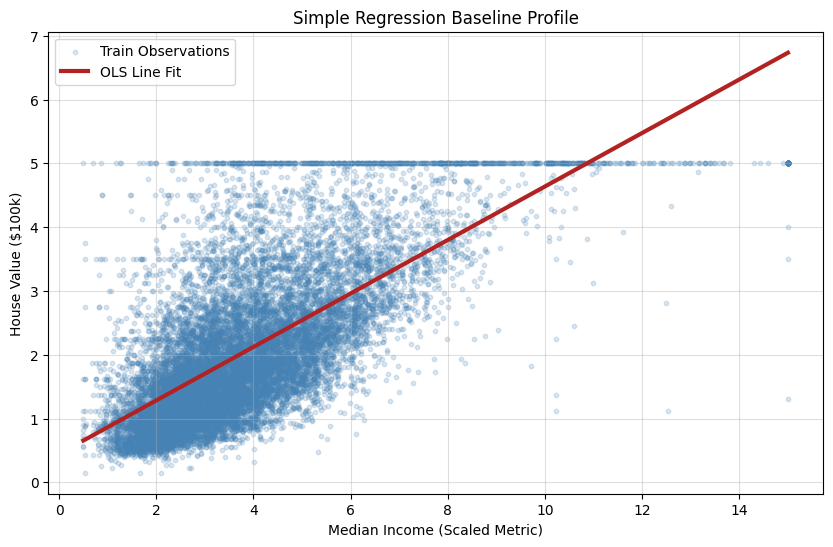

In [5]:
simple_feature = "median_income"

# Isolate columns without modification (Income contains no NaN records)
x_simple = X_train_raw[[simple_feature]].values.astype(float)
x_simple_test = X_test_raw[[simple_feature]].values.astype(float)

w_simple = ols_stable(x_simple, y_train)
y_simple_pred_test = predict_linear(x_simple_test, w_simple)

print("Simple Linear Regression Parameters:")
print(f"Intercept : {w_simple[0]:.4f}")
print(f"Slope     : {w_simple[1]:.4f}")
print(f"Test RMSE : {rmse(y_test, y_simple_pred_test):.4f}")
print(f"Test R²   : {r2_score(y_test, y_simple_pred_test):.4f}\n")

# Visualization of the model fit
x_plot = np.linspace(x_simple.min(), x_simple.max(), 200).reshape(-1, 1)
y_plot = predict_linear(x_plot, w_simple)

plt.scatter(x_simple, y_train, s=10, alpha=0.2, color="steelblue", label="Train Observations")
plt.plot(x_plot, y_plot, color="firebrick", linewidth=3, label="OLS Line Fit")
plt.xlabel("Median Income (Scaled Metric)")
plt.ylabel("House Value ($100k)")
plt.title("Simple Regression Baseline Profile")
plt.legend()
plt.show()

Multivariate OLS System Performance Metrics:
Train RMSE : 0.6759
Test RMSE  : 0.7270
Test R²    : 0.5967

Top 10 Model Weights by Absolute Magnitude:


,Feature Attribute,Calculated Weight,Absolute_Weight
0,Intercept,2.071947,2.071947
8,median_income,0.789044,0.789044
2,latitude,-0.566382,0.566382
1,longitude,-0.562761,0.562761
6,population,-0.463203,0.463203
7,households,0.402337,0.402337
10,bedrooms_per_room,0.168091,0.168091
12,ocean_proximity_INLAND,-0.162570,0.162570
3,housing_median_age,0.141223,0.141223
9,rooms_per_household,0.076994,0.076994


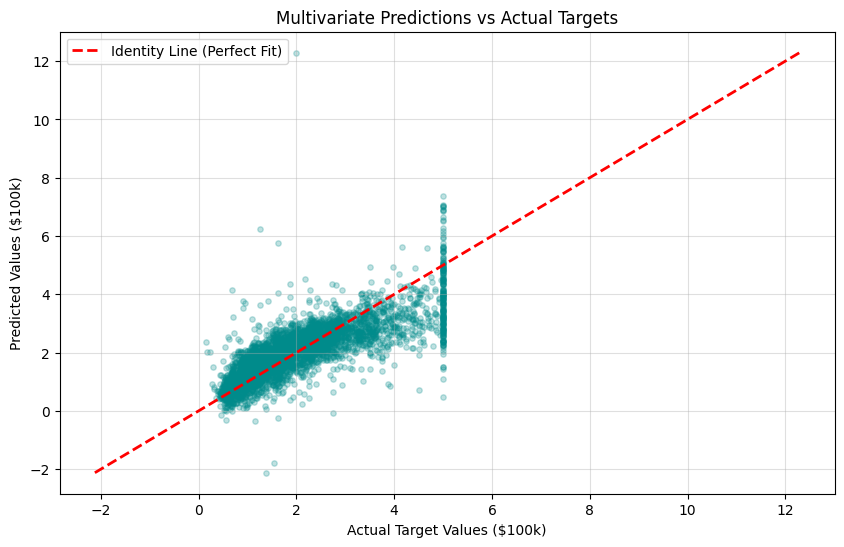

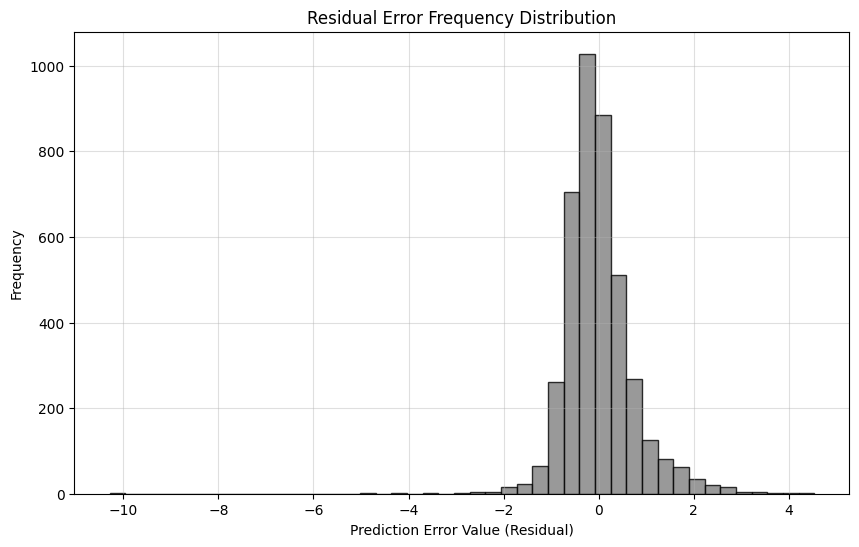

In [6]:
w_multi = ols_stable(X_train, y_train)

train_pred = predict_linear(X_train, w_multi)
test_pred = predict_linear(X_test, w_multi)

print("Multivariate OLS System Performance Metrics:")
print(f"Train RMSE : {rmse(y_train, train_pred):.4f}")
print(f"Test RMSE  : {rmse(y_test, test_pred):.4f}")
print(f"Test R²    : {r2_score(y_test, test_pred):.4f}\n")

# Parameter interpretation assessment
coef_table = pd.DataFrame({
    "Feature Attribute": ["Intercept"] + feature_names,
    "Calculated Weight": w_multi
}).assign(Absolute_Weight=lambda d: d["Calculated Weight"].abs()).sort_values("Absolute_Weight", ascending=False)

print("Top 10 Model Weights by Absolute Magnitude:")
display(coef_table.head(10))

# Fit Evaluation Plot
plt.scatter(y_test, test_pred, alpha=0.25, s=15, color="darkcyan")
axis_limits = [min(y_test.min(), test_pred.min()), max(y_test.max(), test_pred.max())]
plt.plot(axis_limits, axis_limits, "r--", linewidth=2, label="Identity Line (Perfect Fit)")
plt.xlabel("Actual Target Values ($100k)")
plt.ylabel("Predicted Values ($100k)")
plt.title("Multivariate Predictions vs Actual Targets")
plt.legend()
plt.show()

# Error Distribution Diagnostics
residuals = y_test - test_pred
plt.hist(residuals, bins=45, color="grey", edgecolor="black", alpha=0.8)
plt.xlabel("Prediction Error Value (Residual)")
plt.ylabel("Frequency")
plt.title("Residual Error Frequency Distribution")
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


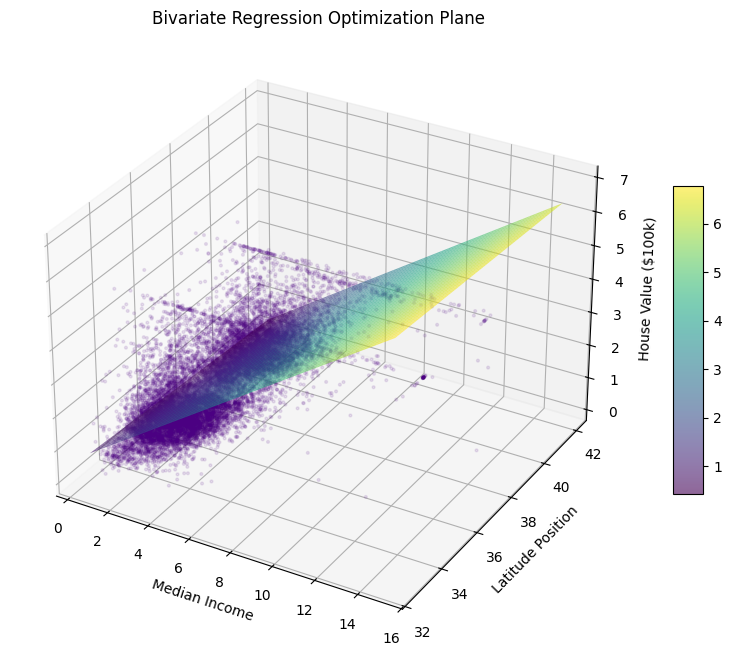

In [7]:
surf_features = ["median_income", "latitude"]
X2_train_subset = X_train_raw[surf_features].copy()
X2_test_subset = X_test_raw[surf_features].copy()

# fit the scaler ONLY on the training subset
sc2 = StandardScaler().fit(X2_train_subset)
X2_train = sc2.transform(X2_train_subset)
X2_test = sc2.transform(X2_test_subset)

w2 = ols_stable(X2_train, y_train)
pred2 = predict_linear(X2_test, w2)

# Create a linear space for both features to build a prediction mesh
grid_x1 = np.linspace(X2_train_subset["median_income"].min(), X2_train_subset["median_income"].max(), 50)
grid_x2 = np.linspace(X2_train_subset["latitude"].min(), X2_train_subset["latitude"].max(), 50)
gx1, gx2 = np.meshgrid(grid_x1, grid_x2)

# Prepare the grid for prediction.
# Hint: The model was trained on SCALED data, so the grid must be scaled too!
grid_raw = np.c_[gx1.ravel(), gx2.ravel()]
grid_scaled = sc2.transform(grid_raw)
grid_pred = predict_linear(grid_scaled, w2).reshape(gx1.shape)

# Build 3D canvas
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

# Scatter the actual training data points
ax.scatter(X2_train_subset["median_income"], X2_train_subset["latitude"], y_train, s=4, alpha=0.1, color="indigo")

# Plot the optimized regression plane
surf = ax.plot_surface(gx1, gx2, grid_pred, cmap="viridis", alpha=0.6, edgecolor="none")

ax.set_xlabel("Median Income")
ax.set_ylabel("Latitude Position")
ax.set_zlabel("House Value ($100k)")
ax.set_title("Bivariate Regression Optimization Plane")
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
plt.show()

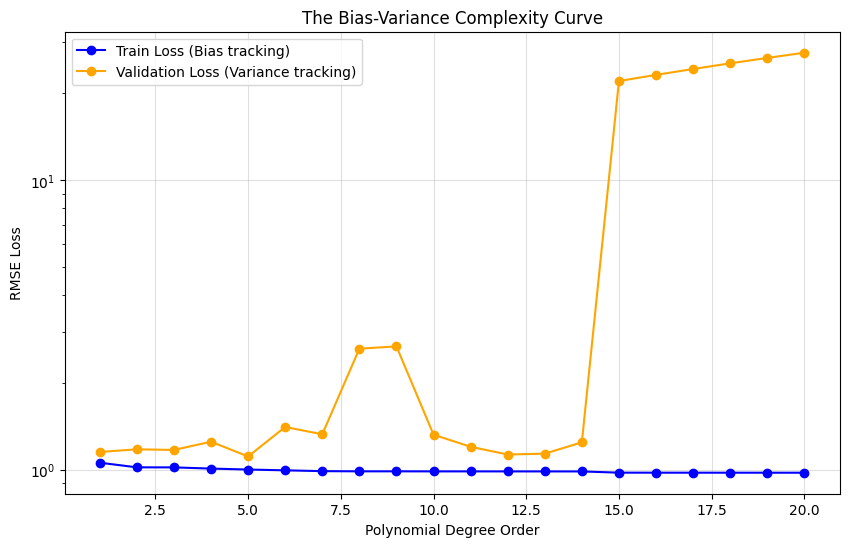

In [8]:
from sklearn.preprocessing import PolynomialFeatures

demo_df = df.sample(n=250, random_state=0).reset_index(drop=True)
x_demo = demo_df[["latitude"]].values.astype(float)
y_demo = demo_df["median_house_value_100k"].values.astype(float)

x_demo_train, x_demo_val, y_demo_train, y_demo_val = train_test_split(
    x_demo, y_demo, test_size=0.5, random_state=1
)

degrees = list(range(1, 21))
train_errors, val_errors = [], []
saved_models = {}

for deg in degrees:
    # Use PolynomialFeatures to expand the single 'latitude' feature into multiple polynomial terms
    poly = PolynomialFeatures(degree=deg, include_bias=False)
    x_tr_poly_raw = poly.fit_transform(x_demo_train)
    x_val_poly_raw = poly.transform(x_demo_val)

    # StandardScaler
    p_scaler = StandardScaler()
    xtr_poly = p_scaler.fit_transform(x_tr_poly_raw)
    xval_poly = p_scaler.transform(x_val_poly_raw)

    # Train using our custom OLS solver
    w_poly = ols_stable(xtr_poly, y_demo_train)
    saved_models[deg] = (poly, p_scaler, w_poly)

    # Calculate and store the RMSE for both training and validation sets
    y_tr_pred = predict_linear(xtr_poly, w_poly)
    y_val_pred = predict_linear(xval_poly, w_poly)

    train_errors.append(rmse(y_demo_train, y_tr_pred))
    val_errors.append(rmse(y_demo_val, y_val_pred))


# Plot error behavior across model complexity
plt.plot(degrees, train_errors, "o-", color="blue", label="Train Loss (Bias tracking)")
plt.plot(degrees, val_errors, "o-", color="orange", label="Validation Loss (Variance tracking)")

plt.xlabel("Polynomial Degree Order")
plt.ylabel("RMSE Loss")
plt.yscale("log")
plt.title("The Bias-Variance Complexity Curve")
plt.legend()
plt.show()

### **Questions: The Bias-Variance Tradeoff**

Analyze the complexity curve generated above and answer the following:
1.  **Identify the 'Elbow':** At which polynomial degree does the **Validation RMSE** reach its minimum before increasing again?
**The validation error hits its first clear low point at degree 5 and reaches its absolute lowest point at degree 12.**
2.  **Structural Transition:** Based on the plot, at what degree does the model officially transition from **Underfitting** (High Bias) to **Overfitting** (High Variance)?
**The model officially switches from underfitting to overfitting right after degree 5. Before degree 5, both errors drop together as the model learns the real geographic trend. After degree 5, the validation error starts bouncing around drastically and completely explodes at degree 15. This shows that the higher degrees are just memorizing random noise instead of finding real patterns.**


### Regularization & The Overfitting Challenge

We are going to intentionally overfit a model using a 20th-degree polynomial. You will observe how the RMSE explodes on the validation set. Then, you will apply **Ridge (L2)** and **Lasso (L1)** to see how they 'tame' these extreme weights.

**Questions:**
*   **Sparsity:** Compare the weights of Ridge and Lasso. Which one actually set some weights to exactly zero? Why is this useful for 'Feature Selection'?

**Answer:** Lasso (L1) is the one that sets some weights to exactly zero. This happens because its sharp geometry aggressively zeros out less important features. This is incredibly useful for feature selection because it automatically strips away the noisy, useless polynomial terms, leaving us with a clean list of only the most impactful features. Ridge (L2) shrinks weights close to zero, but never makes them exactly zero.

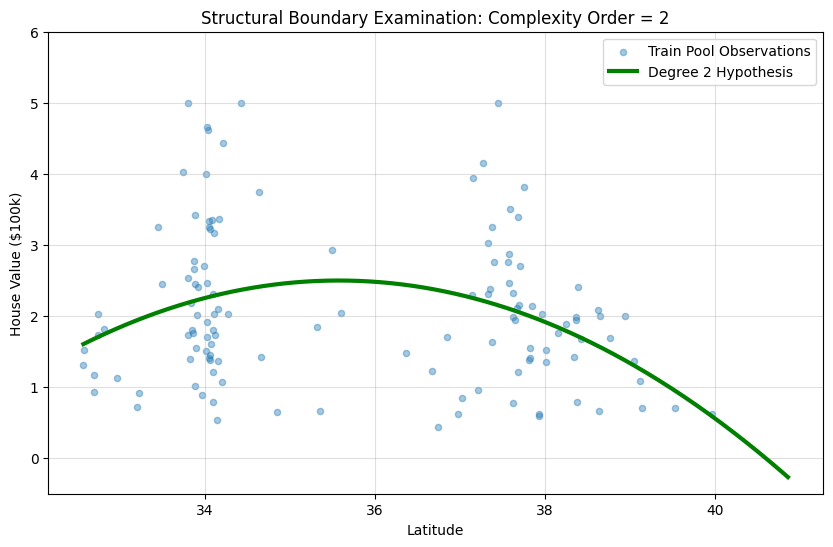

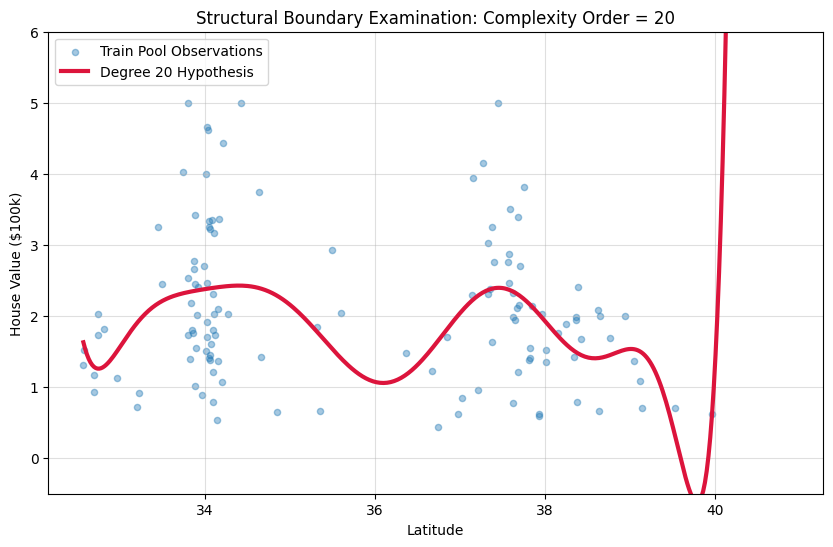

In [9]:
# Visualize contrasting fits: Order 2 vs Order 20
for chosen_degree in [2, 20]:
    # Retrieve the pre-trained components (Poly Transformer, Scaler, and Weights) for the current degree
    poly, p_scaler, w_poly = saved_models[chosen_degree]

    # Generate a smooth range of values for plotting
    x_line = np.linspace(x_demo.min(), x_demo.max(), 400).reshape(-1, 1)

    # Apply the SAME transformations to the plotting line that were applied to the training data
    # Hint: Poly transform -> Scaling transform
    x_line_poly = poly.transform(x_line)
    x_line_scaled = p_scaler.transform(x_line_poly)
    y_line = predict_linear(x_line_scaled, w_poly)

    plt.scatter(x_demo_train, y_demo_train, s=20, alpha=0.4, label="Train Pool Observations")

    # Analyze the plot.
    # Which degree follows the noise (the individual dots) too closely? polynomial with higher degree (degree 20)
    # Which degree captures the general 'shape' of the data better? polynomial with smaller degree (degree 2)
    plt.plot(x_line, y_line, linewidth=3, color="crimson" if chosen_degree==20 else "green", label=f"Degree {chosen_degree} Hypothesis")

    plt.xlabel("Latitude")
    plt.ylabel("House Value ($100k)")
    plt.ylim(-0.5, 6.0)
    plt.title(f"Structural Boundary Examination: Complexity Order = {chosen_degree}")
    plt.legend()
    plt.show()

In [10]:
# Reconstruct baseline degree 20 arrays
deg_order = 20
poly20 = PolynomialFeatures(degree=deg_order, include_bias=False)
xtr_poly20 = poly20.fit_transform(x_demo_train)
xva_poly20 = poly20.transform(x_demo_val)

poly_scaler20 = StandardScaler()
xtr_poly20 = poly_scaler20.fit_transform(xtr_poly20)
xva_poly20 = poly_scaler20.transform(xva_poly20)

# 1. Unregularized OLS Baseline Model
w_ols_20 = ols_stable(xtr_poly20, y_demo_train)

summary_records = [{
    "Model Profile": "OLS (Degree 20)",
    "Train RMSE": rmse(y_demo_train, predict_linear(xtr_poly20, w_ols_20)),
    "Validation RMSE": rmse(y_demo_val, predict_linear(xva_poly20, w_ols_20)),
    "Active Weights (Non-Zero)": int(np.sum(np.abs(w_ols_20[1:]) > 1e-5))
}]

# 2. Iterate Ridge (L2) Regularization Penalties

ridge_lambdas = [0.1, 1.0, 10.0, 100.0]
ridge_saved_weights = {}
for lam in ridge_lambdas:
    w_ridge = ridge_closed_form(xtr_poly20, y_demo_train, lam)
    ridge_saved_weights[lam] = w_ridge
    summary_records.append({
        "Model Profile": f"Ridge (λ={lam})",
        "Train RMSE": rmse(y_demo_train, predict_linear(xtr_poly20, w_ridge)),
        "Validation RMSE": rmse(y_demo_val, predict_linear(xva_poly20, w_ridge)),
        "Active Weights (Non-Zero)": int(np.sum(np.abs(w_ridge[1:]) > 1e-5))
    })

# 3. Iterate Lasso (L1) Coordinate Descent Regularization Penalties

# Why does Lasso produce zeros while Ridge merely makes the weights small?

lasso_lambdas = [0.001, 0.01, 0.05, 0.1]
lasso_saved_weights = {}
for lam in lasso_lambdas:
    w_lasso = lasso_coordinate_descent(xtr_poly20, y_demo_train, lam=lam)
    lasso_saved_weights[lam] = w_lasso
    summary_records.append({
        "Model Profile": f"Lasso (λ={lam})",
        "Train RMSE": rmse(y_demo_train, predict_linear(xtr_poly20, w_lasso)),
        "Validation RMSE": rmse(y_demo_val, predict_linear(xva_poly20, w_lasso)),
        "Active Weights (Non-Zero)": int(np.sum(np.abs(w_lasso[1:]) > 1e-5))
    })

# Render Optimization Analysis Summary Matrix
summary_df = pd.DataFrame(summary_records).sort_values("Validation RMSE")
display(summary_df)

,Model Profile,Train RMSE,Validation RMSE,Active Weights (Non-Zero)
7,Lasso (λ=0.05),1.041560,1.143634,1
8,Lasso (λ=0.1),1.045154,1.144591,1
4,Ridge (λ=100.0),1.037519,1.144833,20
3,Ridge (λ=10.0),1.024760,1.175235,20
1,Ridge (λ=0.1),1.019779,1.176399,20
6,Lasso (λ=0.01),1.025114,1.178493,2
5,Lasso (λ=0.001),1.020211,1.181107,6
2,Ridge (λ=1.0),1.022091,1.188842,20
0,OLS (Degree 20),0.975447,27.595847,20


In [11]:
weight_comparison_df = pd.DataFrame({
    "OLS Unconstrained": w_ols_20[1:9],
    "Ridge (λ=10.0)": ridge_saved_weights[10.0][1:9],
    "Lasso (λ=0.05)": lasso_saved_weights[0.05][1:9]
}, index=[f"Polynomial Term x^{i}" for i in range(1, 9)])

print("Weight Parameter Alignment Matrix (First 8 Terms):")
display(weight_comparison_df)

Weight Parameter Alignment Matrix (First 8 Terms):


,OLS Unconstrained,Ridge (λ=10.0),Lasso (λ=0.05)
Polynomial Term x^1,-3.106146e+09,0.135066,0.0
Polynomial Term x^2,1.175614e+10,0.114790,0.0
Polynomial Term x^3,-1.013486e+10,0.095510,0.0
Polynomial Term x^4,-7.498629e+09,0.077191,0.0
Polynomial Term x^5,5.336679e+09,0.059797,0.0
Polynomial Term x^6,9.810959e+09,0.043289,0.0
Polynomial Term x^7,3.111239e+09,0.027627,-0.0
Polynomial Term x^8,-6.225903e+09,0.012772,-0.0


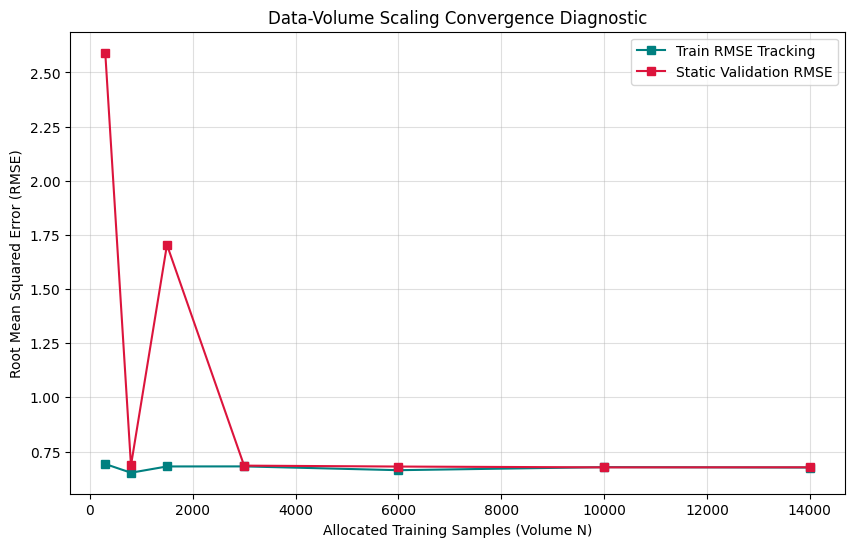

In [12]:
def learning_curve_stable(X_full: np.ndarray, y_full: np.ndarray, sample_steps: list, split_seed: int = 42):
    """Generates error performance curves across incremental dataset scaling volumes."""
    # Split out a persistent, unchanging evaluation validation holdout sequence
    X_train_pool, X_val_static, y_train_pool, y_val_static = train_test_split(
        X_full, y_full, test_size=0.25, random_state=split_seed
    )

    train_metrics, val_metrics = [], []

    for size in sample_steps:
        # Prevent boundary errors by matching max matrix indices
        active_size = min(size, X_train_pool.shape[0])

        X_batch = X_train_pool[:active_size]
        y_batch = y_train_pool[:active_size]

        # Optimize over constrained sample availability using stable OLS SVD
        w_batch = ols_stable(X_batch, y_batch)

        # Calculate RMSE for the current batch and the static validation set
        y_pred_train = predict_linear(X_batch, w_batch)
        y_pred_val = predict_linear(X_val_static, w_batch)

        train_rmse = rmse(y_batch, y_pred_train)
        val_rmse = rmse(y_val_static, y_pred_val)
        train_metrics.append(train_rmse)
        val_metrics.append(val_rmse)


    return train_metrics, val_metrics

# Execute volume diagnostic tracking
training_volume_steps = [300, 800, 1500, 3000, 6000, 10000, 14000]
lc_train, lc_val = learning_curve_stable(X_train, y_train, sample_steps=training_volume_steps)

plt.plot(training_volume_steps, lc_train, "s-", color="teal", label="Train RMSE Tracking")
plt.plot(training_volume_steps, lc_val, "s-", color="crimson", label="Static Validation RMSE")

# Analyze the 'gap' between the two curves.
# At small sample sizes, the gap between the two lines is very large and highly unstable. This huge gap tells us that the complex model is heavily overfitting to the limited data.

# Does it narrow as the volume of training samples increases?
# The gap narrows as the volume of training samples increases. The validation error drops straight down until the two lines completely merge together.

# At what sample size does the model appear to have 'converged'?
# The model reaches its convergence point at exactly 3,000 samples.

plt.xlabel("Allocated Training Samples (Volume N)")
plt.ylabel("Root Mean Squared Error (RMSE)")
plt.title("Data-Volume Scaling Convergence Diagnostic")
plt.legend()
plt.show()

In [13]:
final_evaluation_records = [
    {
        "Hypothesis Structural Model Configuration": "Simple Linear Baseline (Income Column Only)",
        "Out-of-Sample Test RMSE": rmse(y_test, y_simple_pred_test),
        "Out-of-Sample Test R² Score": r2_score(y_test, y_simple_pred_test)
    },
    {
        "Hypothesis Structural Model Configuration": "Multivariate Robust OLS Matrix System",
        "Out-of-Sample Test RMSE": rmse(y_test, test_pred),
        "Out-of-Sample Test R² Score": r2_score(y_test, test_pred)
    },
    {
        "Hypothesis Structural Model Configuration": "Bivariate Geographical Target Plane (Income + Latitude)",
        "Out-of-Sample Test RMSE": rmse(y_test, pred2), # Sourced from isolated block step (7)
        "Out-of-Sample Test R² Score": r2_score(y_test, pred2)
    },
    {
        "Hypothesis Structural Model Configuration": "Poly Order 20 Overfitted Baseline (Small Sample Segment)",
        "Out-of-Sample Test RMSE": summary_df.loc[summary_df["Model Profile"] == "OLS (Degree 20)", "Validation RMSE"].values[0],
        "Out-of-Sample Test R² Score": np.nan  # Degenerate validation structure prevents scaling calculations
    }
]

performance_report_matrix = pd.DataFrame(final_evaluation_records)
print("Comprehensive Out-of-Sample System Evaluation Report Matrix:")
display(performance_report_matrix)

Comprehensive Out-of-Sample System Evaluation Report Matrix:


,Hypothesis Structural Model Configuration,Out-of-Sample Test RMSE,Out-of-Sample Test R² Score
0,Simple Linear Baseline (Income Column Only),0.842090,0.458859
1,Multivariate Robust OLS Matrix System,0.727013,0.596654
2,Bivariate Geographical Target Plane (Income + ...,0.836316,0.466254
3,Poly Order 20 Overfitted Baseline (Small Sampl...,27.595847,NaN


In [14]:
def calculate_adj_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Enriched performance report
n_test = len(y_test)

# Updated records with Adjusted R2
enhanced_records = []
for record in final_evaluation_records:
    new_rec = record.copy()
    r2 = record["Out-of-Sample Test R² Score"]

    # Determine number of features p based on the model name
    # Why does the choice of 'p' affect the Adjusted R² more than the standard R²?
    if "Simple" in record["Hypothesis Structural Model Configuration"]:
        p = 1
    elif "Bivariate" in record["Hypothesis Structural Model Configuration"]:
        p = 2
    elif "Multivariate" in record["Hypothesis Structural Model Configuration"]:
        p = len(feature_names)
    else:
        p = 20 # Polynomial case

    if not np.isnan(r2):
        new_rec["Adjusted R²"] = calculate_adj_r2(r2, n_test, p)
    else:
        new_rec["Adjusted R²"] = np.nan
    enhanced_records.append(new_rec)

enhanced_report = pd.DataFrame(enhanced_records)
print("Enhanced Model Comparison (Including Adjusted R²):")

# Compare the Multivariate OLS vs. the Bivariate model in the resulting table.
# Does the Adjusted R² justify adding all 15 features, or are a few doing most of the work?
display(enhanced_report.style.highlight_min(subset=['Out-of-Sample Test RMSE'], color='lightgreen'))

Enhanced Model Comparison (Including Adjusted R²):


,Hypothesis Structural Model Configuration,Out-of-Sample Test RMSE,Out-of-Sample Test R² Score,Adjusted R²
0,Simple Linear Baseline (Income Column Only),0.842090,0.458859,0.458728
1,Multivariate Robust OLS Matrix System,0.727013,0.596654,0.595183
2,Bivariate Geographical Target Plane (Income + Latitude),0.836316,0.466254,0.465996
3,Poly Order 20 Overfitted Baseline (Small Sample Segment),27.595847,nan,nan


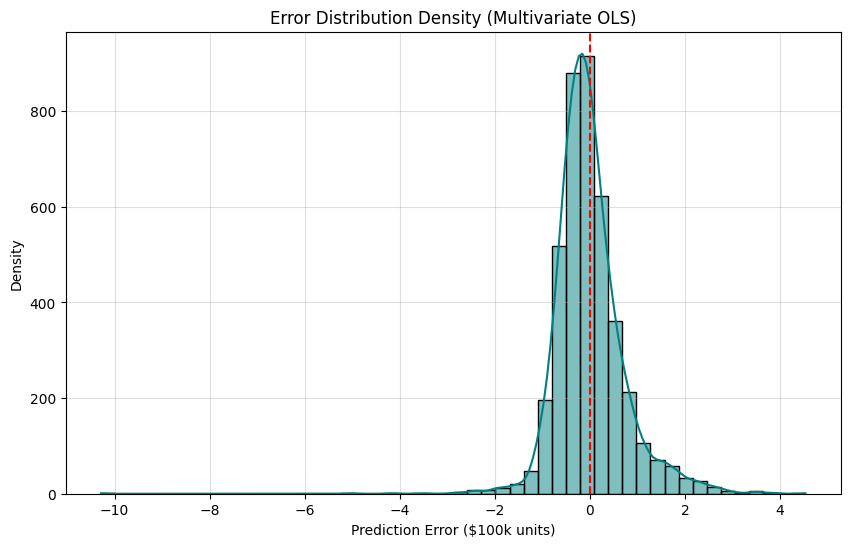

The distribution is mostly centered at 0, suggesting the Multivariate OLS captures the main signal well.


In [15]:
import seaborn as sns

# Diagnostic: Residual analysis of the best model
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='teal', bins=50)
plt.axvline(0, color='red', linestyle='--')
plt.title("Error Distribution Density (Multivariate OLS)")
plt.xlabel("Prediction Error ($100k units)")
plt.ylabel("Density")
plt.show()

print("The distribution is mostly centered at 0, suggesting the Multivariate OLS captures the main signal well.")

## Part 2: Logistic Regression for Classification

Now we transition from predicting a price to predicting a **category**. We will define 'High Value' neighborhoods (Target = 1 if value > median, else 0) and implement Logistic Regression using the Sigmoid function.

### Transitioning to Logistic Regression (Classification)

What if we don't want to predict the price, but simply want to know if a house is 'High Value'? We convert the target into 0s and 1s. You will implement the **Sigmoid Activation Function** to map linear outputs to probabilities.

** Questions:**
*   **The Threshold:** We use 0.5 as the cutoff for classification. In what real-world scenario might you want to move that threshold to 0.8? **We may raise the classification threshold to 0.8 when the real-world cost of a False Positive is exceptionally high.**
*   **Sigmoid Behavior:** As your input $z$ becomes a very large negative number, what value does the probability approach? What does this mean for the model's confidence? **As your input $z$ becomes a very large negative number, the probability approaches 0. This indicates that the model is extremely confident that the data point belongs to the negative class.**

In [16]:
# Prepare Binary Target
median_val = np.median(y_train)
y_train_class = (y_train > median_val).astype(int)
y_test_class = (y_test > median_val).astype(int)

# Implement the Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def logistic_regression_fit(X, y, lr=0.1, epochs=1000):
    Xb = add_intercept(X)
    n, p = Xb.shape
    weights = np.zeros(p)

    # Implement Gradient Descent loop for Logistic Regression
    for _ in range(epochs):
        logits = Xb @ weights

        preds = sigmoid(logits)

        # we use Binary Cross-Entropy loss
        gradient = (Xb.T @ (preds - y)) / n

        weights -= lr * gradient

    return weights


# Train and evaluate
w_logistic = logistic_regression_fit(X_train, y_train_class)
logits = add_intercept(X_test) @ w_logistic
probs = sigmoid(logits)
preds = (probs >= 0.5).astype(int)

accuracy = np.mean(preds == y_test_class)
print(f"Logistic Regression Accuracy: {accuracy:.4f}")

Logistic Regression Accuracy: 0.8249


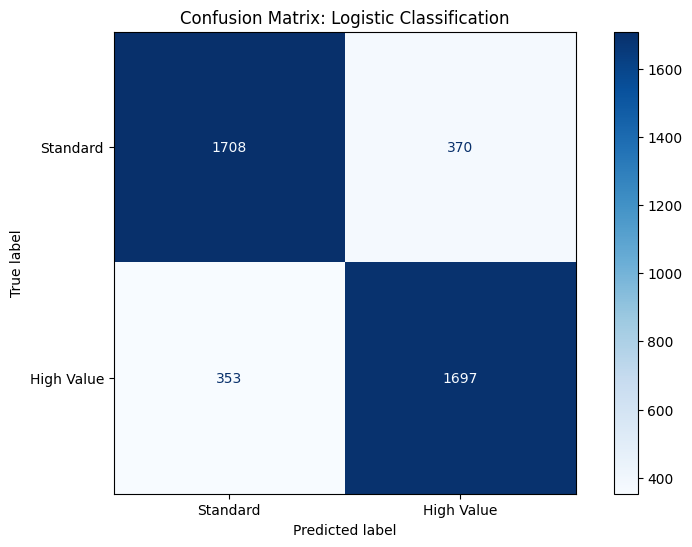

Notebook Summary: We have successfully implemented a full regression suite.


In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test_class, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Standard', 'High Value'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix: Logistic Classification")
plt.grid(False)
plt.show()

print("Notebook Summary: We have successfully implemented a full regression suite.")

### **Questions**

1. **The 'Squashing' Function:** We implemented the Sigmoid function for Logistic Regression. Why is it mathematically impossible for a standard Linear Regression model to reliably predict probabilities without this function?

**Answer:** Standard linear regression can predict values that go below zero or above one. Because probabilities must strictly stay between zero and one, an unconstrained linear model cannot reliably predict them.

2. **Optimization Differences:** Why do we use **Mean Squared Error (MSE)** for predicting house prices, but **Cross-Entropy (Log-Loss)** for predicting 'High Value' categories?

**Answer:** Mean Squared Error measures the continuous mathematical distance between actual and predicted prices. Cross-Entropy instead measures how close a predicted probability is to a correct binary label and heavily penalizes confident wrong guesses.

3. **Metric Selection:** If your Logistic model has 90% accuracy but fails to identify any 'High Value' homes (False Negatives), is it a good model? Which part of the **Confusion Matrix** would alert you to this failure?

**Answer:** That would be a bad model because it completely fails to find high-value homes. The false negative box in our matrix would catch this error because its number would be huge.

4. **Hyperparameter Tuning:** In the `logistic_regression_fit` function, you used a specific `lr` (learning rate). If you set this to 10.0, what would you expect to see in the weights? What if you set it to 0.000001?

**Answer:** A learning rate of 10.0 is too fast and will cause the weights to jump around wildly and break. A learning rate of 0.000001 is too slow and will take forever to learn anything.